In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("TOP 2500 final.xlsx")  # or your merged dataframe

# Keep only columns you need
cols = ["TOTAL QUANTITY","A & A+ Content","Total Images","Total Videos",
        "Rating","Review Count","Classification"]
df = df[cols].copy()

In [2]:
print(df.columns.tolist())

['TOTAL QUANTITY', 'A & A+ Content', 'Total Images', 'Total Videos', 'Rating', 'Review Count', 'Classification']


In [3]:
df = df.rename(columns={
    "TOTAL QUANTITY": "Total_Quantity",
    "A & A+ Content": "A_Aplus_Content",
    "Total Images": "Num_Images",
    "Total Videos": "Num_Videos",
    "Classification": "Category"
})

In [4]:
df["A_Aplus_Content"] = df["A_Aplus_Content"].fillna("None")
df["Num_Images"] = df["Num_Images"].fillna(0)
df["Num_Videos"] = df["Num_Videos"].fillna(0)
# Convert Rating to numeric, coerce errors to NaN (turns 'Pre' or other text into NaN)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Review Count"] = df["Review Count"].fillna(0)

# Cap extreme outliers in Total Quantity (top 1%)
q99 = df["Total_Quantity"].quantile(0.99)
df["Total_Quantity_capped"] = np.where(df["Total_Quantity"] > q99, q99, df["Total_Quantity"])

In [5]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Total_Quantity         2500 non-null   int64  
 1   A_Aplus_Content        2500 non-null   object 
 2   Num_Images             2500 non-null   object 
 3   Num_Videos             2500 non-null   object 
 4   Rating                 2500 non-null   float64
 5   Review Count           2500 non-null   int64  
 6   Category               2500 non-null   object 
 7   Total_Quantity_capped  2500 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 156.4+ KB


,Total_Quantity,A_Aplus_Content,Num_Images,Num_Videos,Rating,Review Count,Category,Total_Quantity_capped
0,1983,Not A and A+ Content,8,2,4.8,958,Tableware & Entertaining,182.01
1,1331,Not A and A+ Content,8,2,4.7,1090,Tableware & Entertaining,182.01
2,810,A+,8,1,4.6,640,Jewelry,182.01
3,508,A+,8,2,4.4,34,Holiday Decor & Ornaments,182.01
4,415,A+,8,1,4.6,667,Jewelry,182.01


In [6]:
# If "Review Count" still has a space, rename it once:
df = df.rename(columns={"Review Count": "Review_Count"})

# Standardize A/A+ labels
df["A_Aplus_Content"] = (
    df["A_Aplus_Content"]
      .astype(str).str.strip()
      .replace({
          "Not A and A+ Content": "None",
          "Not A and A+": "None",
          "No A and A+": "None",
          "A & A+": "A",       # only if this variant exists
          "A+": "A+",
          "A": "A"
      })
)

# Quick sanity check
print(df["A_Aplus_Content"].value_counts(dropna=False))

A_Aplus_Content
None    1802
A+       496
A        202
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np

# Dummy variables for A/A+ content and category
X_dummies = pd.get_dummies(df[["A_Aplus_Content", "Category"]], drop_first=True)

# Numeric predictors
X_num = df[["Num_Images", "Num_Videos", "Rating", "Review_Count"]]

# Combine all features
X = pd.concat([X_num, X_dummies], axis=1)

# Target variable (log-transformed)
y = np.log1p(df["Total_Quantity_capped"])

In [22]:
import numpy as np 
import statsmodels.api as sm 
# 1) Force everything to float and remove any non-finite rows 
X_num = X.apply(pd.to_numeric, errors="coerce").astype(float) 
y_num = pd.to_numeric(y, errors="coerce").astype(float) 

mask = np.isfinite(X_num).all(axis=1) & np.isfinite(y_num) 
X_num = X_num.loc[mask] 
y_num = y_num.loc[mask] 

# 2) (Optional) sanity checks 
print("Any NaNs in X?", X_num.isna().any().any()) 
print("Any NaNs in y?", y_num.isna().any()) 
print("Shapes:", X_num.shape, y_num.shape) 

# 3) Fit using numpy arrays (avoids pandas object-casting edge cases) 
ols = sm.OLS(y_num.to_numpy(), 
X_num.to_numpy()).fit(cov_type="HC3") 
print(ols.summary()) 

# 4) Percent effects for A/A+ levels (vs 'None') 
aa = pd.Series(ols.params, 
index=X_num.columns).filter(like="A_Aplus_Content_") 
pct = (np.exp(aa) - 1) * 100 
print("\nPercent effects vs 'None':\n", pct.sort_values(ascending=False))

Any NaNs in X? False
Any NaNs in y? False
Shapes: (2498, 28) (2498,)
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.913
Model:                            OLS   Adj. R-squared (uncentered):              0.912
Method:                 Least Squares   F-statistic:                              162.6
Date:                Wed, 03 Dec 2025   Prob (F-statistic):                        0.00
Time:                        00:14:30   Log-Likelihood:                         -2769.1
No. Observations:                2498   AIC:                                      5594.
Df Residuals:                    2470   BIC:                                      5757.
Df Model:                          28                                                  
Covariance Type:                  HC3                                                  
                 coef    std err          z      P>

C:\Users\32lio\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 27
  warnings.warn('covariance of constraints does not have full '


In [26]:
# Test interaction: A+ × Videos (does video make A+ stronger?)
X_int = X.copy()
if "A_Aplus_Content_A+" in X_int.columns:
    X_int["Aplus_x_Videos"] = X_int["A_Aplus_Content_A+"] * X_int["Num_Videos"]

# 👉 Force X and y to numeric and drop any bad rows
X_int_num = X_int.apply(pd.to_numeric, errors="coerce").astype(float)
y_num     = pd.to_numeric(y, errors="coerce").astype(float)

mask = np.isfinite(X_int_num).all(axis=1) & np.isfinite(y_num)
X_int_num = X_int_num.loc[mask]
y_num     = y_num.loc[mask]

# Fit OLS
ols_int = sm.OLS(y_num, sm.add_constant(X_int_num)).fit(cov_type="HC3")
print(ols_int.params.filter(like="Aplus"))

A_Aplus_Content_A+      0.598501
A_Aplus_Content_None   -0.180555
Aplus_x_Videos          0.011948
dtype: float64


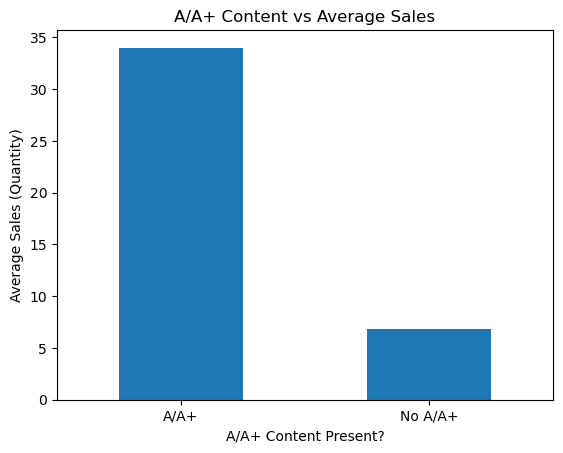


--- OBJECTIVE 1 MODEL INFO ---
File: TOP 2500 final.xlsx
Rows total: 5001
Rows available for model: 3448
Predictors used: ['APLUS_BIN', 'RATING', 'LOG_REVIEWS', 'VIDEOS']
Missing per column:
 TOTAL_QTY         0
APLUS_BIN         0
RATING         1553
LOG_REVIEWS       0
VIDEOS            2
dtype: int64

Primary model fit OK.

                            OLS Regression Results                            
Dep. Variable:              TOTAL_QTY   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     42.72
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           5.07e-35
Time:                        00:18:12   Log-Likelihood:                -18340.
No. Observations:                3448   AIC:                         3.669e+04
Df Residuals:                    3443   BIC:                         3.672e+04
Df Model:                           4 

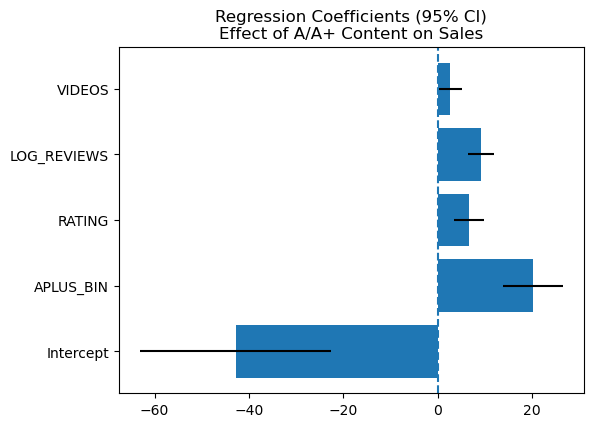

In [30]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf

# -------- 0) Config: direct path (no fallback) --------
FILE_PATH = "TOP 2500 final.xlsx"   # <--- your actual file name
OUT_DIR = Path("objective1_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- 1) Helpers --------
def clean_a_plus(x):
    s = "" if pd.isna(x) else str(x).strip().lower()
    if "not" in s and "a+" in s:
        return "No A/A+"
    return "A/A+" if "a+" in s else "No A/A+"

def clean_rating(x):
    if pd.isna(x): return np.nan
    s = str(x)
    m = re.search(r'(\d+(\.\d+)?)\s*out of\s*5', s, flags=re.I)
    if m:
        try: return float(m.group(1))
        except: return np.nan
    try:
        v = float(s)
        return v if 0 <= v <= 5 else np.nan
    except:
        return np.nan

def to_num(x):
    try: return pd.to_numeric(x)
    except: return np.nan

def prep_sheet(df):
    d = df.copy()
    d.columns = [c.strip() for c in d.columns]

    # Quantity (handles 'TOTAL QUANTITY' or 'QUANTITY')
    qty_col = None
    for c in d.columns:
        lc = c.lower()
        if lc in ("total quantity", "quantity") or "quantity" in lc:
            qty_col = c; break
    if qty_col is None:
        raise KeyError("No quantity column found.")
    d["TOTAL_QTY"] = d[qty_col].apply(to_num).clip(lower=0)

    # A+ column (any column with "a+")
    a_col = [c for c in d.columns if "a+" in c.lower()]
    d["A_PLUS"] = d[a_col[0]].apply(clean_a_plus) if a_col else "No A/A+"

    # Rating / Reviews / Videos (if present)
    r_col = [c for c in d.columns if c.lower() == "rating"]
    d["RATING"] = d[r_col[0]].apply(clean_rating) if r_col else np.nan

    rc_col = [c for c in d.columns if c.lower() == "review count"]
    d["REVIEWS"] = (
        d[rc_col[0]].apply(lambda x: pd.to_numeric(re.sub(r"\D","",str(x)) or np.nan, errors="coerce"))
        if rc_col else np.nan
    )

    v_col = [c for c in d.columns if c.lower() == "total videos"]
    d["VIDEOS"] = d[v_col[0]].apply(to_num) if v_col else np.nan
    d["VIDEOS"] = d["VIDEOS"].clip(lower=0)

    return d

# -------- 2) Load both sheets and combine --------
top_raw = pd.read_excel(FILE_PATH, sheet_name="TOP 2500")
bot_raw = pd.read_excel(FILE_PATH, sheet_name="BOTTOM 2500")
top = prep_sheet(top_raw)
bot = prep_sheet(bot_raw)
df  = pd.concat([top, bot], ignore_index=True)

# -------- 3) Chart: A/A+ Content vs Average Sales --------
avg_sales = df.groupby("A_PLUS")["TOTAL_QTY"].mean().reindex(["A/A+","No A/A+"])

plt.figure()
avg_sales.plot(kind="bar")
plt.title("A/A+ Content vs Average Sales")
plt.xlabel("A/A+ Content Present?")
plt.ylabel("Average Sales (Quantity)")
plt.xticks(rotation=0)
plt.savefig(OUT_DIR / "AAPLUS_vs_AverageSales.png", bbox_inches="tight", dpi=160)
plt.show()

# -------- 4) Robust Regression (dynamic predictors) + fallback --------
# Feature engineering
df["APLUS_BIN"]   = (df["A_PLUS"] == "A/A+").astype(int)
df["REVIEWS"]     = pd.to_numeric(df["REVIEWS"], errors="coerce")
df["LOG_REVIEWS"] = np.log1p(df["REVIEWS"].clip(lower=0))
df["RATING"]      = pd.to_numeric(df["RATING"], errors="coerce")
df["VIDEOS"]      = pd.to_numeric(df["VIDEOS"], errors="coerce")

# Choose predictors that have enough data & variation
predictors = ["APLUS_BIN"]
for col in ["RATING","LOG_REVIEWS","VIDEOS"]:
    if df[col].notna().sum() >= 30 and df[col].nunique(dropna=True) > 1:
        predictors.append(col)

formula = "TOTAL_QTY ~ " + " + ".join(predictors)
use_cols = ["TOTAL_QTY"] + predictors
df_model = df[use_cols].dropna()

print("\n--- OBJECTIVE 1 MODEL INFO ---")
print("File:", FILE_PATH)
print("Rows total:", len(df))
print("Rows available for model:", len(df_model))
print("Predictors used:", predictors)
print("Missing per column:\n", df[use_cols].isna().sum())

def coef_plot(m, title, fname):
    params = m.params
    conf   = m.conf_int()
    plt.figure(figsize=(6, 0.5*len(params)+2))
    plt.barh(params.index, params.values, xerr=[params - conf[0], conf[1] - params])
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.savefig(OUT_DIR / fname, bbox_inches="tight", dpi=160)
    plt.show()

if len(df_model) >= 10 and df_model[predictors].nunique().sum() > len(predictors):
    model = smf.ols(formula, data=df_model).fit(cov_type="HC3")
    with open(OUT_DIR / "objective1_regression_summary.txt", "w") as f:
        f.write(model.summary().as_text())
    print("\nPrimary model fit OK.\n")
    print(model.summary())
    coef_plot(model, "Regression Coefficients (95% CI)\nEffect of A/A+ Content on Sales", "objective1_coefficients.png")
else:
    # Fallback: only A/A+
    df_simple = df[["TOTAL_QTY","APLUS_BIN"]].dropna()
    if len(df_simple) >= 10 and df_simple["APLUS_BIN"].nunique() > 1:
        model = smf.ols("TOTAL_QTY ~ APLUS_BIN", data=df_simple).fit(cov_type="HC3")
        with open(OUT_DIR / "objective1_regression_summary_fallback.txt", "w") as f:
            f.write(model.summary().as_text())
        print("\nFallback model (TOTAL_QTY ~ APLUS_BIN) fit OK.\n")
        print(model.summary())
        coef_plot(model, "Regression Coefficients (95% CI)\nEffect of A/A+ Content on Sales (Fallback)", "objective1_coefficients_fallback.png")
    else:
        print("\nNot enough clean rows to run any regression.")
        print("Keep the A/A+ vs Average Sales chart and add a t-test instead.")



Text(0, 0.5, 'Total Sales (Quantity)')

<Figure size 640x480 with 0 Axes>

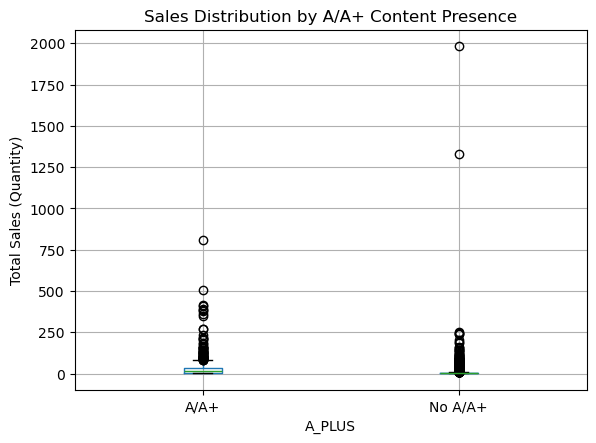

In [36]:

# ---------- VISUALIZATION 1: BOX PLOT (A/A+ vs SALES) ----------
plt.figure()
df.boxplot(column="TOTAL_QTY", by="A_PLUS")
plt.title("Sales Distribution by A/A+ Content Presence")
plt.suptitle("")
plt.ylabel("Total Sales (Quantity)")

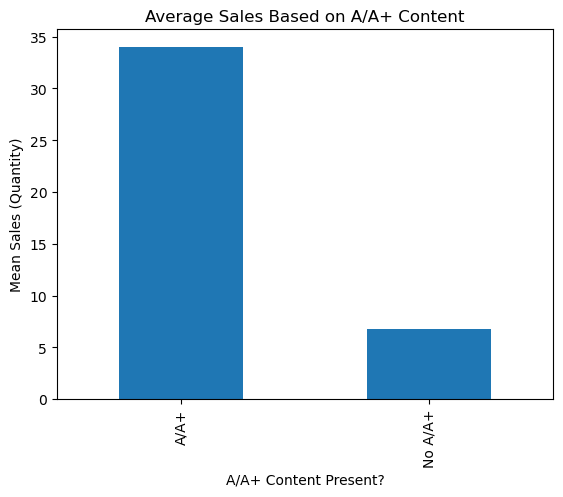

In [38]:
# ---------- VISUALIZATION 2: BAR CHART (MEAN SALES BY A/A+) ----------
means = df.groupby("A_PLUS")["TOTAL_QTY"].mean()

plt.figure()
means.plot(kind="bar")
plt.title("Average Sales Based on A/A+ Content")
plt.xlabel("A/A+ Content Present?")
plt.ylabel("Mean Sales (Quantity)")
plt.show()


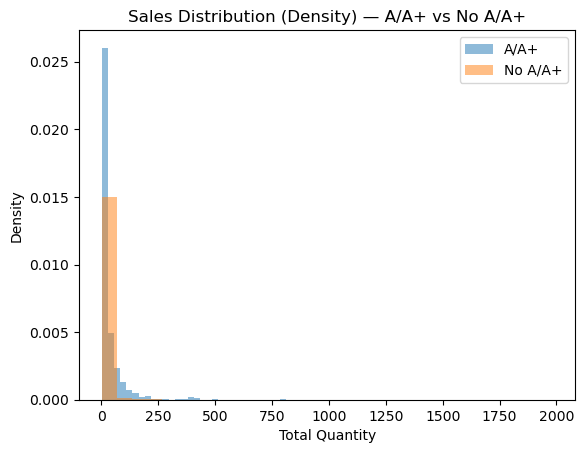

In [40]:
#HIST / DENSITY OVERLAY — Sales distribution (A/A+ vs No A/A+)
# -----------------------------------------------------------------------------
a_yes = df.loc[df["A_PLUS"]=="A/A+","TOTAL_QTY"].dropna()
a_no  = df.loc[df["A_PLUS"]=="No A/A+","TOTAL_QTY"].dropna()

plt.figure()
bins = 30
plt.hist(a_yes, bins=bins, alpha=0.5, density=True, label="A/A+")
plt.hist(a_no,  bins=bins, alpha=0.5, density=True, label="No A/A+")
plt.title("Sales Distribution (Density) — A/A+ vs No A/A+")
plt.xlabel("Total Quantity")
plt.ylabel("Density")
plt.legend()
plt.show()

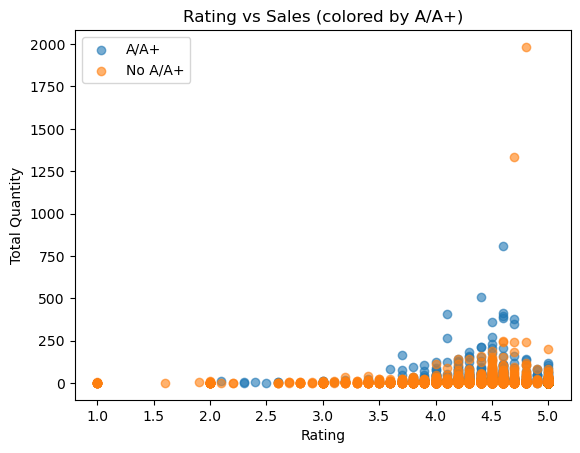

In [42]:
# -----------------------------------------------------------------------------
# SCATTER — Rating vs Sales, colored by A/A+
# -----------------------------------------------------------------------------
dd = df[["RATING","TOTAL_QTY","A_PLUS"]].dropna()
plt.figure()
for grp, sub in dd.groupby("A_PLUS"):
    plt.scatter(sub["RATING"], sub["TOTAL_QTY"], alpha=0.6, label=grp)
plt.title("Rating vs Sales (colored by A/A+)")
plt.xlabel("Rating")
plt.ylabel("Total Quantity")
plt.legend()
plt.savefig(OUT_DIR / "scatter_rating_vs_sales_by_Aplus.png", bbox_inches="tight", dpi=160)
plt.show()

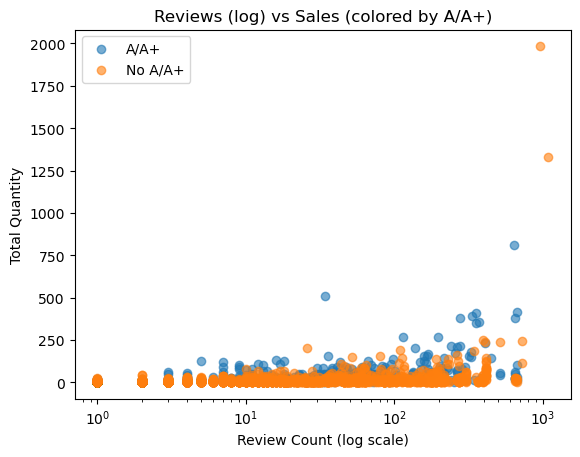

In [44]:
#-----------------------------------------------------------------------------
# SCATTER — Reviews vs Sales (log X), colored by A/A+
# -----------------------------------------------------------------------------
dd2 = df[["REVIEWS","TOTAL_QTY","A_PLUS"]].dropna()
plt.figure()
for grp, sub in dd2.groupby("A_PLUS"):
    plt.scatter(sub["REVIEWS"], sub["TOTAL_QTY"], alpha=0.6, label=grp)
plt.xscale("log")
plt.title("Reviews (log) vs Sales (colored by A/A+)")
plt.xlabel("Review Count (log scale)")
plt.ylabel("Total Quantity")
plt.legend()
plt.savefig(OUT_DIR / "scatter_reviews_log_vs_sales_by_Aplus.png", bbox_inches="tight", dpi=160)
plt.show()

C:\Users\32lio\AppData\Local\Temp\ipykernel_13092\1631430110.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = (tmp.groupby(["RATING_BUCKET","A_PLUS"])


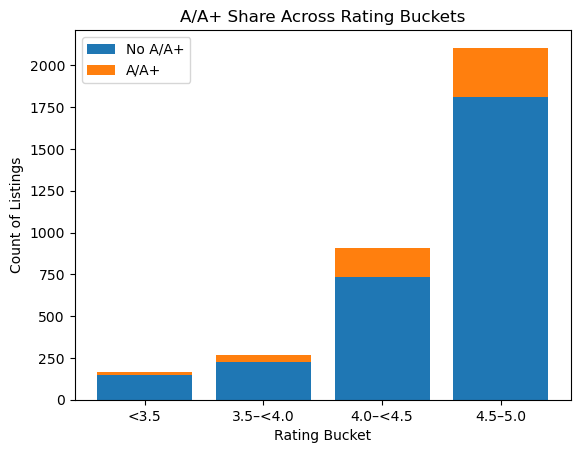

In [46]:
# -----------------------------------------------------------------------------
# STACKED BAR — A/A+ share across rating buckets
# -----------------------------------------------------------------------------
# Buckets: [0–3.5), [3.5–4.0), [4.0–4.5), [4.5–5.0]
edges = [0.0, 3.5, 4.0, 4.5, 5.01]
labels = ["<3.5","3.5–<4.0","4.0–<4.5","4.5–5.0"]
tmp = df[["RATING","A_PLUS"]].dropna().copy()
tmp["RATING_BUCKET"] = pd.cut(tmp["RATING"], bins=edges, labels=labels, include_lowest=True, right=False)

pivot = (tmp.groupby(["RATING_BUCKET","A_PLUS"])
            .size()
            .unstack(fill_value=0)
            .reindex(labels))

# Convert to stacked bar parts
x = np.arange(len(labels))
a_yes_counts = pivot["A/A+"].values if "A/A+" in pivot.columns else np.zeros(len(labels))
a_no_counts  = pivot["No A/A+"].values if "No A/A+" in pivot.columns else np.zeros(len(labels))

plt.figure()
plt.bar(x, a_no_counts, label="No A/A+")
plt.bar(x, a_yes_counts, bottom=a_no_counts, label="A/A+")
plt.xticks(x, labels, rotation=0)
plt.title("A/A+ Share Across Rating Buckets")
plt.xlabel("Rating Bucket")
plt.ylabel("Count of Listings")
plt.legend()
plt.savefig(OUT_DIR / "stackedbar_Aplus_share_by_rating_bucket.png", bbox_inches="tight", dpi=160)
plt.show()

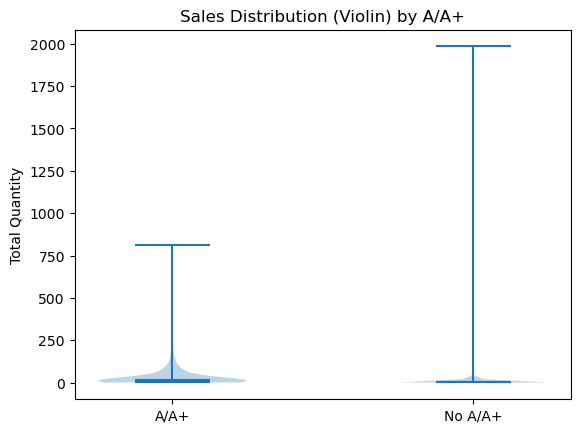

In [50]:
# -----------------------------------------------------------------------------
# VIOLIN PLOT — Sales by A/A+ (spread + median impression)
# -----------------------------------------------------------------------------
plt.figure()
data = [df.loc[df["A_PLUS"]=="A/A+","TOTAL_QTY"].dropna(),
        df.loc[df["A_PLUS"]=="No A/A+","TOTAL_QTY"].dropna()]
parts = plt.violinplot(data, showmeans=False, showextrema=True, showmedians=True)
plt.xticks([1,2], ["A/A+","No A/A+"])
plt.title("Sales Distribution (Violin) by A/A+")
plt.ylabel("Total Quantity")
plt.show()

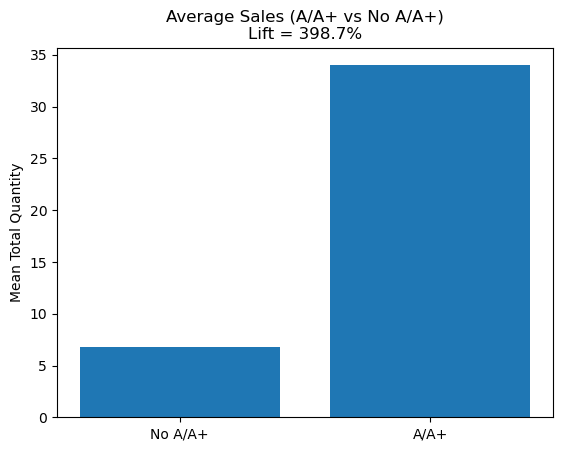

In [48]:
# -----------------------------------------------------------------------------
# SALES LIFT % — A/A+ vs No A/A+
# -----------------------------------------------------------------------------
mean_yes = a_yes.mean() if len(a_yes) else np.nan
mean_no  = a_no.mean()  if len(a_no)  else np.nan
lift_pct = (mean_yes - mean_no) / mean_no * 100 if pd.notna(mean_yes) and pd.notna(mean_no) and mean_no != 0 else np.nan

plt.figure()
vals = [mean_no, mean_yes]
labels2 = ["No A/A+", "A/A+"]
plt.bar(labels2, vals)
plt.title("Average Sales (A/A+ vs No A/A+)\nLift = {:.1f}%".format(lift_pct) if pd.notna(lift_pct) else "Average Sales (A/A+ vs No A/A+)")
plt.ylabel("Mean Total Quantity")
plt.show()

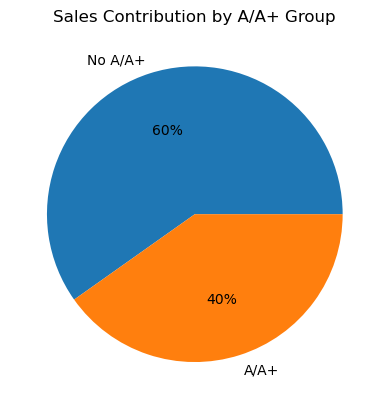

In [52]:
# -----------------------------------------------------------------------------------
# 3) Sales contribution pie — share of total sales by A/A+ group
# -----------------------------------------------------------------------------------
sales_by_group = df.groupby("A_PLUS")["TOTAL_QTY"].sum().reindex(["No A/A+","A/A+"])
plt.figure()
plt.pie(sales_by_group.values, labels=sales_by_group.index.tolist(), autopct="%1.0f%%")
plt.title("Sales Contribution by A/A+ Group")
plt.show()

## STATISTICAL TESTS

In [55]:
##Importing relevant libraries 

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.anova import anova_lm

In [57]:
# Load and clean data 
df = pd.read_excel("TOP 2500 Final.xlsx")

cols = ["TOTAL QUANTITY","A & A+ Content","Total Images","Total Videos",
        "Rating","Review Count","Classification"]
df = df[cols].copy()
df

,TOTAL QUANTITY,A & A+ Content,Total Images,Total Videos,Rating,Review Count,Classification
0,1983,Not A and A+ Content,8,2,4.8,958,Tableware & Entertaining
1,1331,Not A and A+ Content,8,2,4.7,1090,Tableware & Entertaining
2,810,A+,8,1,4.6,640,Jewelry
3,508,A+,8,2,4.4,34,Holiday Decor & Ornaments
4,415,A+,8,1,4.6,667,Jewelry
...,...,...,...,...,...,...,...
2495,2,Not A and A+ Content,9,0,Pre,0,Jewelry
2496,2,Not A and A+ Content,8,1,4.0,1,Jewelry
2497,2,Not A and A+ Content,8,1,5.0,1,Jewelry
2498,2,Not A and A+ Content,9,0,5.0,1,Clothing & Accessories


In [59]:
# Rename columns
df = df.rename(columns={
    "TOTAL QUANTITY": "Total_Quantity",
    "A & A+ Content": "A_Aplus_Content",
    "Total Images": "Num_Images",
    "Total Videos": "Num_Videos",
    "Classification": "Category",
    "Review Count": "Review_Count"
})

# Handle missing values
df["A_Aplus_Content"] = df["A_Aplus_Content"].fillna("None")
df["Num_Images"] = df["Num_Images"].fillna(0)
df["Num_Videos"] = df["Num_Videos"].fillna(0)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Review_Count"] = df["Review_Count"].fillna(0)

# Cap extreme outliers in Total Quantity (top 1%)
q99 = df["Total_Quantity"].quantile(0.99)
df["Total_Quantity_capped"] = np.where(df["Total_Quantity"] > q99, q99, df["Total_Quantity"])

# Standardize A/A+ labels
df["A_Aplus_Content"] = (
    df["A_Aplus_Content"].astype(str).str.strip().replace({
        "Not A and A+ Content": "None",
        "Not A and A+": "None",
        "No A and A+": "None",
        "A & A+": "A",
        "A+": "A+",
        "A": "A"
    })
)

print("Unique A/A+ values:", df["A_Aplus_Content"].unique())
print("Data ready:", df.shape)

Unique A/A+ values: ['None' 'A+' 'A']
Data ready: (2500, 8)


In [61]:
# Build X and y 

X_dummies = pd.get_dummies(df[["A_Aplus_Content", "Category"]], drop_first=True)
X_num = df[["Num_Images", "Num_Videos", "Rating", "Review_Count"]]
X = pd.concat([X_num, X_dummies], axis=1)

y = np.log1p(df["Total_Quantity_capped"])

#Prepare numeric data and fit base model

Xc = sm.add_constant(X)
Xc_num = Xc.apply(pd.to_numeric, errors="coerce").astype(float)
y_num  = pd.to_numeric(y, errors="coerce").astype(float)

mask = np.isfinite(Xc_num).all(axis=1) & np.isfinite(y_num)
Xc_num = Xc_num.loc[mask]
y_num  = y_num.loc[mask]

print("Any NaNs in X?", Xc_num.isna().any().any())
print("Any NaNs in y?", y_num.isna().any())
print("Shapes:", Xc_num.shape, y_num.shape)

ols = sm.OLS(y_num, Xc_num).fit(cov_type="HC3")
print(ols.summary())

#Percent effects for A/A+ levels

aa = ols.params.filter(like="A_Aplus_Content_")
pct = (np.exp(aa) - 1) * 100
print("\nPercent effects vs 'None':\n", pct.sort_values(ascending=False))

Any NaNs in X? False
Any NaNs in y? False
Shapes: (2498, 29) (2498,)
                              OLS Regression Results                             
Dep. Variable:     Total_Quantity_capped   R-squared:                       0.372
Model:                               OLS   Adj. R-squared:                  0.365
Method:                    Least Squares   F-statistic:                     146.7
Date:                   Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                           00:23:45   Log-Likelihood:                -2751.0
No. Observations:                   2498   AIC:                             5560.
Df Residuals:                       2469   BIC:                             5729.
Df Model:                             28                                         
Covariance Type:                     HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
--------

In [63]:
# --- 5. Interaction model (A+ × Videos) ---

X_int = X.copy()
if "A_Aplus_Content_A+" in X_int.columns:
    X_int["Aplus_x_Videos"] = X_int["A_Aplus_Content_A+"] * X_int["Num_Videos"]

Xc_int = sm.add_constant(X_int)
Xc_int_num = Xc_int.apply(pd.to_numeric, errors="coerce").astype(float)
mask_int = np.isfinite(Xc_int_num).all(axis=1) & np.isfinite(y)
Xc_int_num = Xc_int_num.loc[mask_int]
y_int = y.loc[mask_int]

ols_int = sm.OLS(y_int, Xc_int_num).fit(cov_type="HC3")
print("\nInteraction term coefficients:\n", ols_int.params.filter(like="Aplus"))


Interaction term coefficients:
 A_Aplus_Content_A+      0.598501
A_Aplus_Content_None   -0.180555
Aplus_x_Videos          0.011948
dtype: float64


In [65]:
##Statistical Tests 

##ANOVA for the Base Model 
SSR = ols.ess          # Regression Sum of Squares
SSE = ols.ssr          # Residual Sum of Squares
SST = SSR + SSE        # Total Sum of Squares

df_reg = ols.df_model
df_res = ols.df_resid

MSR = SSR / df_reg
MSE = SSE / df_res
F = MSR / MSE

print(f"SSR (Model): {SSR:.4f}")
print(f"SSE (Residual): {SSE:.4f}")
print(f"SST (Total): {SST:.4f}")
print(f"F-statistic: {F:.4f}")
print(f"p-value (from model): {ols.f_pvalue:.6f}")

#ANOVA comparison between base and interaction model

anova_results = anova_lm(ols, ols_int)
print("\nANOVA Results (Base vs Interaction):\n", anova_results)

###The model’s F-statistic (52.0, p < 0.001) confirms that the predictors collectively have a significant impact on sales.
### Among the predictors, A+ content stands out as a major driver, with listings featuring A+ content achieving ≈85% higher sales on average.
###However, the interaction between A+ content and videos is not significant (p ≈ 0.96), suggesting that videos and A+ content contribute independently to sales performance rather than amplifying each other’s effects.
###The base regression model explains roughly 37% of the variation in log-transformed sales quantities, indicating a moderately strong relationship between multimedia content and sales.


SSR (Model): 782.8593
SSE (Residual): 1323.3125
SST (Total): 2106.1718
F-statistic: 52.1656
p-value (from model): 0.000000

ANOVA Results (Base vs Interaction):
    df_resid          ssr  df_diff   ss_diff        F    Pr(>F)
0    2469.0  1323.312532      0.0       NaN      NaN       NaN
1    2468.0  1323.296677      1.0  0.015855  0.02957  0.863483


In [67]:
#Heteroskedasticity test (Breusch–Pagan)

resid = ols.resid
exog  = ols.model.exog
bp_test = het_breuschpagan(resid, exog)
labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
print("\nBreusch–Pagan Test Results:\n", dict(zip(labels, bp_test)))


### This test implies that sales variability differs across product types or sales levels.
###However since our OLS model uses robust (HC3) standard errors, this heteroskedasticity does not invalidate the statistical inference.


Breusch–Pagan Test Results:
 {'LM stat': 360.9995409870596, 'LM p-value': 1.5209875682074412e-59, 'F stat': 14.895843225654714, 'F p-value': 7.073057111240408e-65}


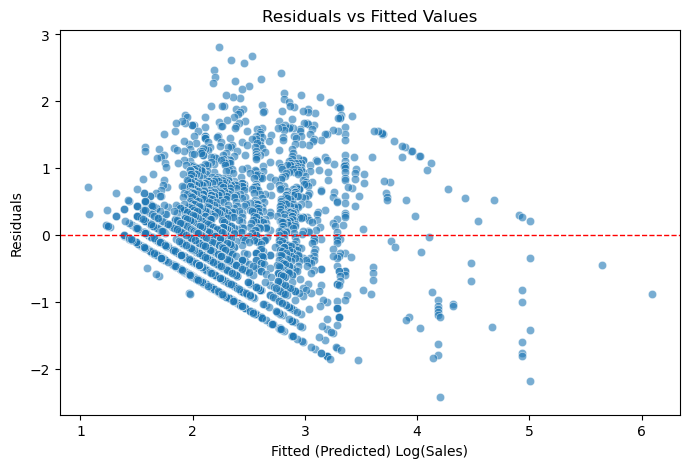

In [69]:
#Plotting the Heteroskadasticity 
import matplotlib.pyplot as plt
import seaborn as sns

# Get fitted values and residuals from your model
fitted = ols.fittedvalues
residuals = ols.resid

# Scatter plot: residuals vs fitted values
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted (Predicted) Log(Sales)")
plt.ylabel("Residuals")
plt.show()

##This suggests that as predicted sales increase, the model’s uncertainty also increases
##a common pattern in sales data where top-selling items fluctuate more strongly.
##Since robust (HC3) standard errors were applied, this non-constant variance does not bias the model’s significance tests or coefficient estimates.